In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Load Data

df = pd.read_csv("D:/Flight Delay Prediction/data/processed/flight_features.csv")

In [6]:
#Basic Information

print("Shape:", df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nFirst 5 Rows")
display(df.head())

Shape: (528201, 28)

Columns
Index(['flight_id', 'flight_date', 'marketing_airline_network', 'origin',
       'dest', 'crs_dep_time', 'dep_delay', 'arr_delay', 'distance',
       'crs_elapsed_time', 'cancelled', 'diverted', 'created_at',
       'delay_status', 'month', 'day', 'day_name', 'day_of_week', 'quarter',
       'is_weekend', 'departure_hour', 'departure_minute', 'departure_period',
       'distance_category', 'flight_duration_minutes', 'flight_duration_hours',
       'duration_category', 'delay_severity'],
      dtype='object')

Data Types
flight_id                      int64
flight_date                   object
marketing_airline_network     object
origin                        object
dest                          object
crs_dep_time                  object
dep_delay                      int64
arr_delay                      int64
distance                       int64
crs_elapsed_time               int64
cancelled                       bool
diverted                        bool
c

,flight_id,flight_date,marketing_airline_network,origin,dest,crs_dep_time,dep_delay,arr_delay,distance,crs_elapsed_time,...,quarter,is_weekend,departure_hour,departure_minute,departure_period,distance_category,flight_duration_minutes,flight_duration_hours,duration_category,delay_severity
0,1,2025-01-15,DL,MSP,RDU,2026-07-09 12:50:00,-3,-14,980,149,...,1,0,12,50,Afternoon,Medium,149,2.48,Medium Flight,On Time
1,2,2025-01-16,DL,MSP,RDU,2026-07-09 14:35:00,-4,-23,980,149,...,1,0,14,35,Afternoon,Medium,149,2.48,Medium Flight,On Time
2,3,2025-01-17,DL,MSP,RDU,2026-07-09 14:35:00,-4,-14,980,149,...,1,0,14,35,Afternoon,Medium,149,2.48,Medium Flight,On Time
3,4,2025-01-20,DL,MSP,RDU,2026-07-09 14:35:00,-2,15,980,149,...,1,0,14,35,Afternoon,Medium,149,2.48,Medium Flight,On Time
4,5,2025-01-21,DL,MSP,RDU,2026-07-09 14:35:00,2,-10,980,149,...,1,0,14,35,Afternoon,Medium,149,2.48,Medium Flight,On Time


In [9]:
#Missing Values

missing = df.isnull().sum()
print(missing)

flight_id                    0
flight_date                  0
marketing_airline_network    0
origin                       0
dest                         0
crs_dep_time                 0
dep_delay                    0
arr_delay                    0
distance                     0
crs_elapsed_time             0
cancelled                    0
diverted                     0
created_at                   0
delay_status                 0
month                        0
day                          0
day_name                     0
day_of_week                  0
quarter                      0
is_weekend                   0
departure_hour               0
departure_minute             0
departure_period             0
distance_category            0
flight_duration_minutes      0
flight_duration_hours        0
duration_category            0
delay_severity               0
dtype: int64


In [10]:
#Duplicate Values
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [11]:
#Summary
df.describe()

,flight_id,dep_delay,arr_delay,distance,crs_elapsed_time,delay_status,month,day,day_of_week,quarter,is_weekend,departure_hour,departure_minute,flight_duration_minutes,flight_duration_hours
count,528201.000000,528201.000000,528201.000000,528201.000000,528201.000000,528201.000000,528201.0,528201.000000,528201.000000,528201.0,528201.000000,528201.000000,528201.000000,528201.000000,528201.000000
mean,264101.000000,0.032291,-7.433280,805.467646,147.115297,0.105636,1.0,16.169032,3.009459,1.0,0.249621,12.802197,26.676901,147.115297,2.451933
std,152478.639105,12.448930,16.921301,592.510303,72.705831,0.307371,0.0,9.059377,1.908881,0.0,0.432794,4.753808,18.298361,72.705831,1.211765
min,1.000000,-48.000000,-55.000000,31.000000,25.000000,0.000000,1.0,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,25.000000,0.420000
25%,132051.000000,-7.000000,-19.000000,370.000000,94.000000,0.000000,1.0,8.000000,1.000000,1.0,0.000000,9.000000,10.000000,94.000000,1.570000
50%,264101.000000,-4.000000,-10.000000,649.000000,130.000000,0.000000,1.0,16.000000,3.000000,1.0,0.000000,13.000000,26.000000,130.000000,2.170000
75%,396151.000000,2.000000,2.000000,1050.000000,179.000000,0.000000,1.0,24.000000,4.000000,1.0,0.000000,17.000000,42.000000,179.000000,2.980000
max,528201.000000,267.000000,44.000000,5095.000000,693.000000,1.000000,1.0,31.000000,6.000000,1.0,1.000000,23.000000,59.000000,693.000000,11.550000


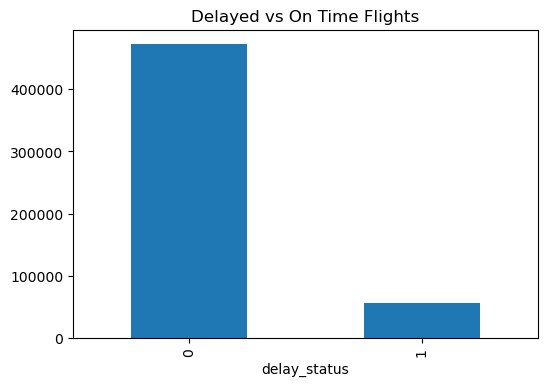

In [14]:
#Analysis
df["delay_status"].value_counts()


df["delay_status"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Delayed vs On Time Flights")
plt.show()

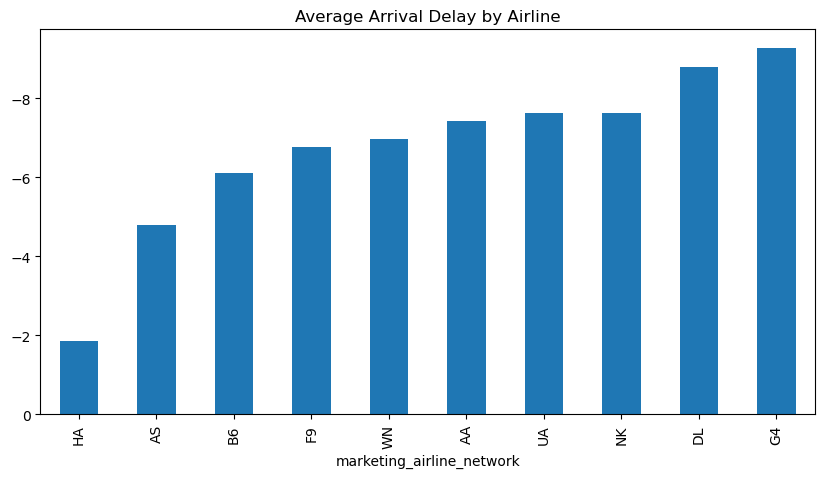

In [17]:
#Airline Analysis
airline_delay = (
    df.groupby("marketing_airline_network")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
)
airline_delay


airline_delay.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Arrival Delay by Airline")
plt.gca().invert_yaxis()
plt.show()

In [18]:
#Airport Analysis
origin_delay = (
    df.groupby("origin")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

origin_delay

origin
CKB    11.000000
PUW     7.089888
BRW     4.275862
SLN     3.086957
MGW     2.638889
SMX     2.000000
DLG     1.730769
YKM     1.052632
ERI     0.831325
BET     0.131148
Name: arr_delay, dtype: float64

In [19]:
destination_delay = (
    df.groupby("dest")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

destination_delay

dest
CKB    12.333333
SHR     6.127660
JMS     2.490196
PUW     1.840909
BIH     1.367347
AKN     1.125000
LBL     1.085106
BRW     0.400000
PSE     0.108108
LAR     0.081081
Name: arr_delay, dtype: float64

departure_period
Afternoon   -6.590539
Evening     -6.088116
Morning     -8.718268
Night       -7.225532
Name: arr_delay, dtype: float64


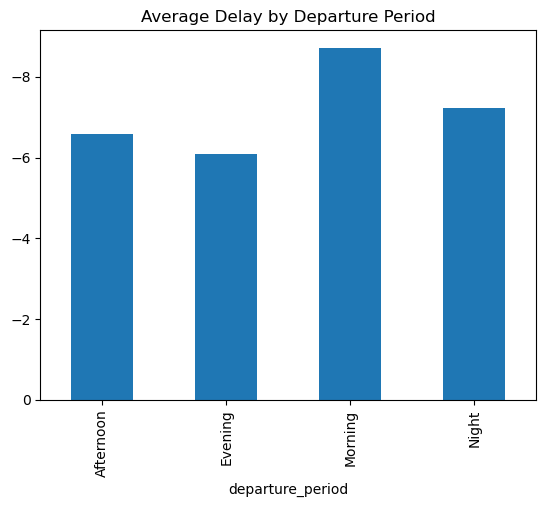

In [23]:
#Time Analysis
departure = (
    df.groupby("departure_period")["arr_delay"]
    .mean()
)

print(departure)

departure.plot(
    kind="bar"
)

plt.title("Average Delay by Departure Period")
plt.gca().invert_yaxis()
plt.show()

In [24]:
#Flight Analysis
distance = (
    df.groupby("distance_category")["arr_delay"]
    .mean()
)

print(distance)

distance_category
Long     -9.874288
Medium   -7.063337
Short    -7.156436
Name: arr_delay, dtype: float64


In [26]:
duration = (
    df.groupby("duration_category")["arr_delay"]
    .mean()
)
print(duration)

duration_category
Long Flight     -10.084696
Medium Flight    -7.316717
Short Flight     -6.905078
Name: arr_delay, dtype: float64


                         flight_id  dep_delay  arr_delay  distance  \
flight_id                 1.000000   0.035490   0.007201 -0.004482   
dep_delay                 0.035490   1.000000   0.653507  0.066739   
arr_delay                 0.007201   0.653507   1.000000 -0.049613   
distance                 -0.004482   0.066739  -0.049613  1.000000   
crs_elapsed_time         -0.019009   0.061053  -0.059331  0.978076   
delay_status             -0.009807   0.586108   0.701276  0.006256   
month                          NaN        NaN        NaN       NaN   
day                       0.003513  -0.120179  -0.120103 -0.025611   
day_of_week               0.003909   0.040116   0.042866  0.010717   
quarter                        NaN        NaN        NaN       NaN   
is_weekend                0.007007   0.048542   0.042332  0.011552   
departure_hour           -0.017138   0.116603   0.066884 -0.024144   
departure_minute          0.000862   0.036232   0.020113  0.002288   
flight_duration_minu

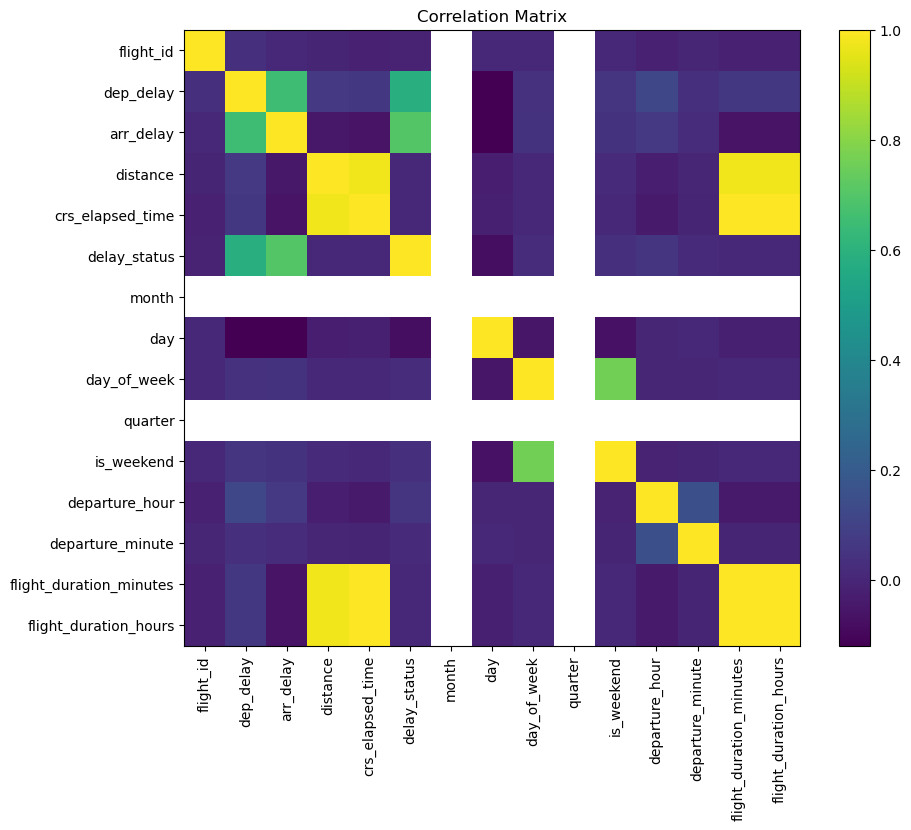

In [34]:
#Correlation
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
print(corr)

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")
plt.savefig('correlation_map.png', dpi=300, bbox_inches='tight')
plt.show()


                         distance  flight_duration_minutes  day_of_week  \
distance                 1.000000                 0.978076     0.010717   
flight_duration_minutes  0.978076                 1.000000     0.009542   
day_of_week              0.010717                 0.009542     1.000000   
is_weekend               0.011552                 0.009840     0.761297   
departure_hour          -0.024144                -0.041363    -0.000582   
departure_minute         0.002288                -0.003021    -0.001873   
delay_status             0.006256                 0.009501     0.023898   

                         is_weekend  departure_hour  departure_minute  \
distance                   0.011552       -0.024144          0.002288   
flight_duration_minutes    0.009840       -0.041363         -0.003021   
day_of_week                0.761297       -0.000582         -0.001873   
is_weekend                 1.000000       -0.007036         -0.002358   
departure_hour            -0.00703

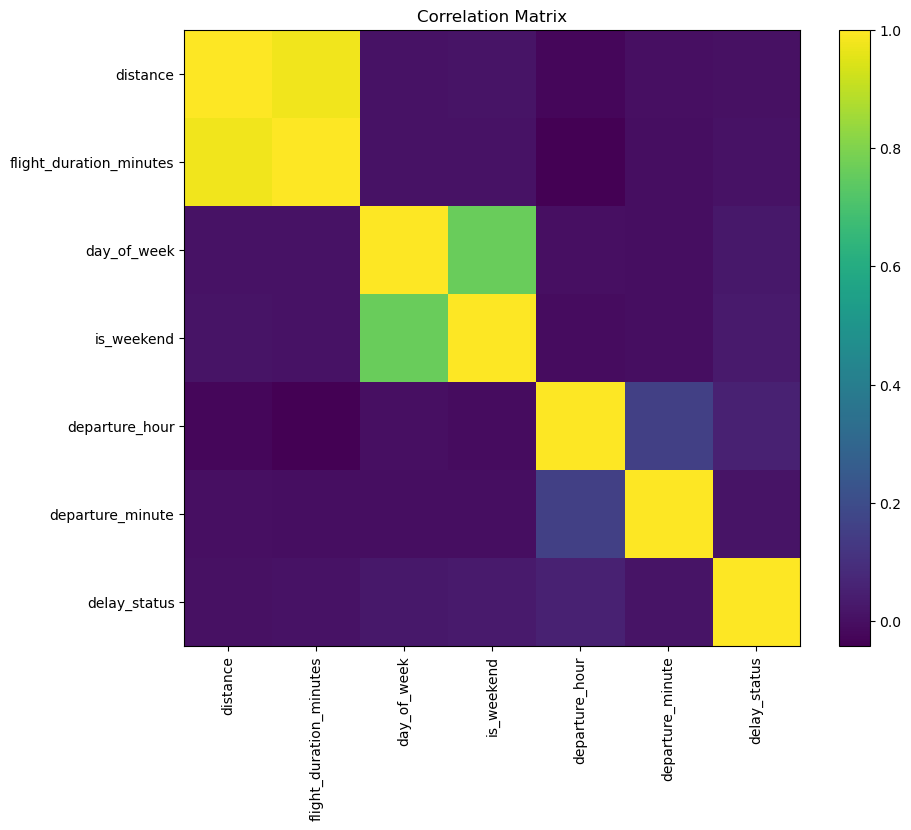

In [37]:
features = [
    "distance",
    "flight_duration_minutes",
    "day_of_week",
    "is_weekend",
    "departure_hour",
    "departure_minute",
    "delay_status"
]

corr = df[features].corr()
print(corr)

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")
#plt.savefig('correlation_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
#Drop columns for ML Model

drop_columns = [
    "flight_id",
    "flight_date",
    "month",
    "quarter",
    "arr_delay",
    "dep_delay",
    "flight_duration_hours"
]

marketing_airline_network
B6    14.572543
F9    13.767008
G4    12.484487
AS    11.626234
NK    10.946859
UA    10.783096
AA    10.720089
DL     9.916610
WN     9.390243
HA     7.770763
Name: delay_status, dtype: float64


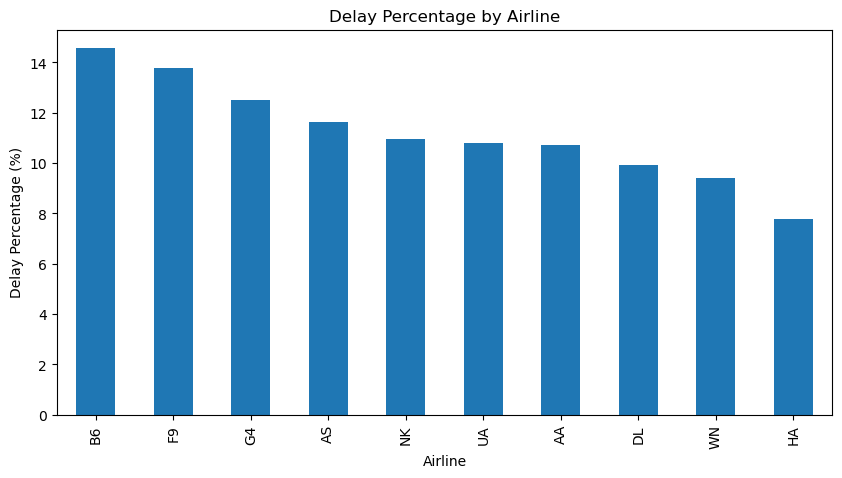

In [40]:
#Delay rate by airline
airline_delay_rate = (
    df.groupby("marketing_airline_network")["delay_status"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(airline_delay_rate)

plt.figure(figsize=(10,5))

airline_delay_rate.plot(kind="bar")

plt.title("Delay Percentage by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Percentage (%)")

plt.show()

departure_period
Afternoon    11.259465
Evening      12.675994
Morning       8.863092
Night        11.855923
Name: delay_status, dtype: float64


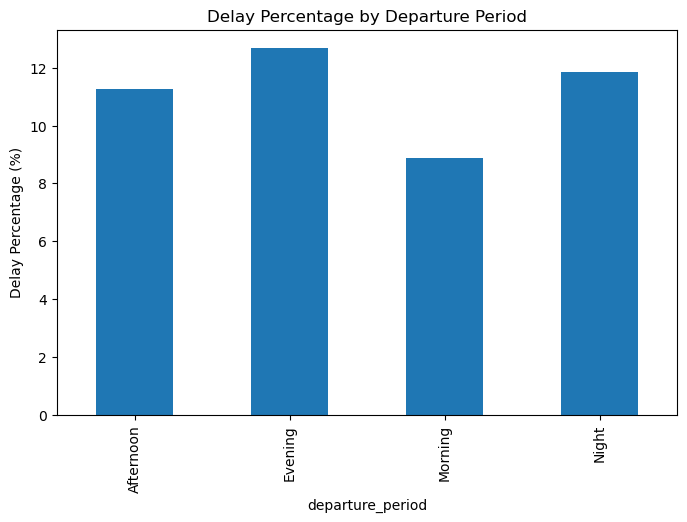

In [42]:
#Delay rate by departure period
period_delay = (
    df.groupby("departure_period")["delay_status"]
    .mean()
    * 100
)

print(period_delay)
plt.figure(figsize=(8,5))

period_delay.plot(kind="bar")

plt.title("Delay Percentage by Departure Period")
plt.ylabel("Delay Percentage (%)")

plt.show()

day_name
Monday       12.190815
Tuesday       8.891580
Wednesday     7.837081
Thursday     10.021359
Friday       10.979042
Saturday     12.144686
Sunday       12.499104
Name: delay_status, dtype: float64


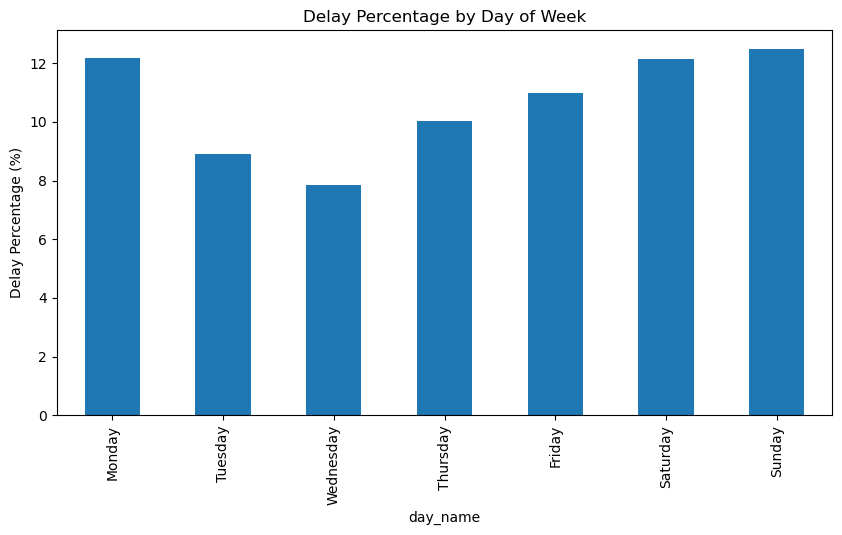

In [44]:
#Delay rate by day of week
weekday_delay = (
    df.groupby("day_name")["delay_status"]
    .mean()
    * 100
)

weekday_delay = weekday_delay.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

print(weekday_delay)


plt.figure(figsize=(10,5))

weekday_delay.plot(kind="bar")

plt.title("Delay Percentage by Day of Week")

plt.ylabel("Delay Percentage (%)")

plt.show()

distance_category
Long      10.160648
Medium    11.210317
Short      9.797949
Name: delay_status, dtype: float64


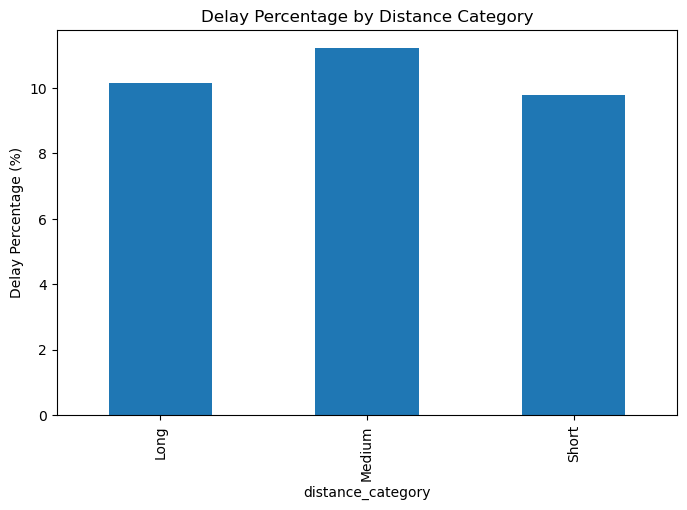

In [46]:
#Delay rate by distance
distance_delay = (
    df.groupby("distance_category")["delay_status"]
    .mean()
    * 100
)

print(distance_delay)

plt.figure(figsize=(8,5))

distance_delay.plot(kind="bar")

plt.title("Delay Percentage by Distance Category")

plt.ylabel("Delay Percentage (%)")

plt.show()

In [47]:
#most delayed routes
routes = (
    df.groupby(["origin", "dest"])["delay_status"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    * 100
)

print(routes)

origin  dest
ALB     DFW     100.0
DTW     PDX     100.0
SAN     BZN     100.0
LAS     ANC     100.0
RSW     HOU     100.0
PDX     DTW     100.0
STL     PNS     100.0
FWA     LAS     100.0
LGB     MCI     100.0
SGF     LAX     100.0
Name: delay_status, dtype: float64


delay_status
0    89.436408
1    10.563592
Name: proportion, dtype: float64


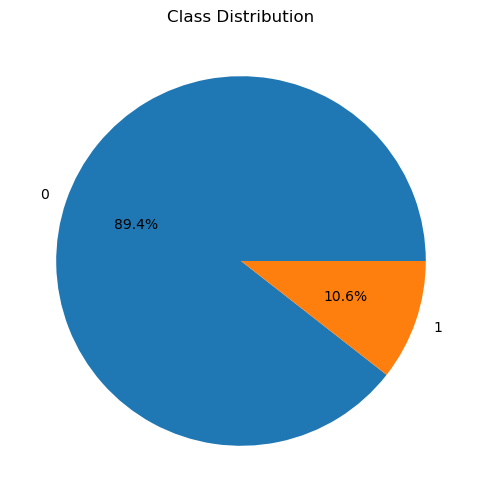

In [49]:
#Dataset Balance
class_distribution = (
    df["delay_status"]
    .value_counts(normalize=True)
    * 100
)

print(class_distribution)

plt.figure(figsize=(6,6))

class_distribution.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Class Distribution")

plt.show()

In [50]:
#Feature Importance
important_features = [
    "marketing_airline_network",
    "origin",
    "dest",
    "distance",
    "flight_duration_minutes",
    "departure_hour",
    "departure_period",
    "day_of_week",
    "is_weekend"
]

print(df[important_features].head())

  marketing_airline_network origin dest  distance  flight_duration_minutes  \
0                        DL    MSP  RDU       980                      149   
1                        DL    MSP  RDU       980                      149   
2                        DL    MSP  RDU       980                      149   
3                        DL    MSP  RDU       980                      149   
4                        DL    MSP  RDU       980                      149   

   departure_hour departure_period  day_of_week  is_weekend  
0              12        Afternoon            2           0  
1              14        Afternoon            3           0  
2              14        Afternoon            4           0  
3              14        Afternoon            0           0  
4              14        Afternoon            1           0  
